## Summary of key insights

- Most features are categorical (all but price and sale date), many of them take a huge number of different values, many values appearing only once, which will make prediction difficult without some pooling

- The price distribution is very right skewed, so that the log-price is more convenient to study.

- Almost all sales were done after 1985. A very strong inflation is visible over time since 1985, stronger than general consumer index inflation. Perhaps a feature "inflation corrected price" is needed.

- Cellos are the most valued, followed by violins and viols and bows. Several instrument types are very rare.

- Among makers totalling over 50 sales, the 10 most expansive and the 10 least expansive display a spectacularly different price distribution. The most expensive are concentrated in Italy.

- In general, the more ancient the instrument, the more valuable. Yet 1500 makers lack the date, representing 6k sales, which is a significant caveat. Ideally, we could write some script to fetch their date from some other database on internet.

## Importation of packages and data frames

In [282]:
import pandas as pd
import numpy as np
import seaborn as sns

In [283]:
sales=pd.read_csv("cozio_sales_ALL.csv")

In [284]:
sales

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
0,2919,"Achner, Michael",Violin,Wallgau,Tarisio,"Feb 20, 2010",354,4200.0,2721.0,3107.0,usd
1,2919,"Achner, Michael",Violin,Mittenwald,Bongartz's,"Apr 27, 1987",145,2838.0,1702.0,NaN,NaN
2,2611,"Achner, Philip",Violin,Mittenwald,Tarisio,"May 17, 2018",123,24000.0,17759.0,20330.0,usd
3,2611,"Achner, Philip",Violin,NaN,Bongartz's,"Nov 15, 2008",138,3884.0,2613.0,3064.0,NaN
4,2611,"Achner, Philip",Violin,Mittenwald,Sotheby's,"Mar 27, 1990",16,2146.0,1320.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
57164,844,"Zygmuntowicz, Samuel",Violin,"Brooklyn, NY",Tarisio,"Apr 27, 2012",311,108000.0,66560.0,81639.0,usd
57165,844,"Zygmuntowicz, Samuel",Violin,"New York, NY",Brompton's,"Dec 14, 2009",-,15634.0,9600.0,10674.0,gbp
57166,844,"Zygmuntowicz, Samuel",Violin,NaN,Brompton's,"Dec 14, 2009",1,15634.0,9600.0,10674.0,gbp
57167,844,"Zygmuntowicz, Samuel",Violin,"Brooklyn, NY",Tarisio,"May 8, 2003",144,130000.0,81078.0,113686.0,usd


There are 11 columns in the original Tarisio-Cozio data set; maker_id and maker_name are probably the same thing, they identify a maker. The bold currency (usd, gbp or eur) indicates in which currency the sale was made. It is often missing. 

## Duplicates and missingness analysis

In [285]:
sales[sales.duplicated()]
#there are no exact duplicates

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency


In [286]:
sales[sales.duplicated(['maker_id','type','sale_date','usd'],keep=False)]

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
52,1988,"Adam, Jean 'Grand'",Violin Bow,Mirecourt,Sotheby's,"Oct 5, 2010",-,27851.0,17500.0,20211.0,gbp
53,1988,"Adam, Jean 'Grand'",Violin Bow,NaN,Sotheby's,"Oct 5, 2010",118,27851.0,17500.0,20211.0,NaN
95,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255A,8865.0,5980.0,NaN,NaN
96,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255AA,8865.0,5980.0,NaN,NaN
176,15601,"Aguzzi, Dario",Violin,Pavia,Brompton's,"Jun 7, 2021",184,2834.0,2000.0,2330.0,gbp
...,...,...,...,...,...,...,...,...,...,...,...
57069,1193,"Zanoli, Giacomo",Violin,NaN,Butterfield & Butterfield,"Oct 18, 1999",8046,28750.0,17195.0,26454.0,usd
57075,1680,"Zanotti, Antonio",Violin,Mantua,Sotheby's,"Nov 7, 2006",-,80212.0,42000.0,62887.0,gbp
57076,1680,"Zanotti, Antonio",Violin,NaN,Sotheby's,"Nov 7, 2006",139,80212.0,42000.0,62887.0,gbp
57165,844,"Zygmuntowicz, Samuel",Violin,"New York, NY",Brompton's,"Dec 14, 2009",-,15634.0,9600.0,10674.0,gbp


We do seem to see 3 pairs of duplicates here, but the rows with lots 255A and 255AA are probably genuinely different (a sublot in the world of auction house). We'll look for sales which in only differ in the lot being "-" instead of a proper values and consider them duplicates.

In [287]:
cols = ['sale_date', 'maker_id', 'type', 'usd', 'gbp', 'auction_house']
mask_dash = sales['lot'] == '-'
has_twin = sales[mask_dash].apply(
    lambda r: ((sales[cols] == r[cols]).all(axis=1) & (sales['lot'] != '-')).any(),
    axis=1
)
sales = sales.drop(index=sales[mask_dash][has_twin].index)

In [288]:
len(sales)
# we lost 188 rows, kind of negligible. We can therefore consider the original file as essentially duplicates-free.

56981

In [289]:
sales[sales.duplicated(['maker_id','type','sale_date','usd'],keep=False)]

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
95,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255A,8865.0,5980.0,NaN,NaN
96,1946,"Adam, Jean I",Cello Bow,Mirecourt,Sotheby's,"Nov 2, 1993",255AA,8865.0,5980.0,NaN,NaN
176,15601,"Aguzzi, Dario",Violin,Pavia,Brompton's,"Jun 7, 2021",184,2834.0,2000.0,2330.0,gbp
177,15601,"Aguzzi, Dario",Violin,Pavia,Brompton's,"Jun 7, 2021",199,2834.0,2000.0,2330.0,gbp
526,8,"Amati, Antonio & Girolamo",Violin,Cremona,Phillip's,"Nov 15, 1990",176,49575.0,25300.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
56568,1176,"Withers, George Thomas Henry",Violin Bow,London,Sotheby's,"Sep 16, 1987",145,543.0,330.0,NaN,gbp
56589,971,"Wolff, Brothers",Violin,NaN,Bonhams,"Mar 11, 2009",60,1488.0,1080.0,1164.0,gbp
56590,971,"Wolff, Brothers",Violin,NaN,Bonhams,"Mar 11, 2009",61,1488.0,1080.0,1164.0,gbp
56603,971,"Wolff, Brothers",Violin,Kreuznach,Phillip's,"Jun 18, 2001",250,702.0,500.0,818.0,gbp


These are clearly not duplicates, but let's check if maybe some are duplicates up to NAs.

In [290]:
keys = ['maker_id','type','sale_date','usd','auction_house']


sales = sales.sort_values(by=cols)


sales[sales['lot'].isna() & sales.duplicated(keys,keep=False)]
# they seem to be duplicates, with the pattern city missing vs city filled as above. Only two duplicates, perfectly negligible.

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
32159,1309,"Martin, Jean-Joseph",Violin Bow,Paris,NaN,"Mar 22, 2024",NaN,4236.0,3360.0,3916.0,gbp
32160,1309,"Martin, Jean-Joseph",Violin Bow,NaN,NaN,"Mar 22, 2024",NaN,4236.0,3360.0,3916.0,gbp
44154,647,"Sartory, Eugène Nicolas",Violin Bow,Paris,NaN,"Oct 28, 2025",NaN,30270.0,22800.0,26027.0,gbp
44161,647,"Sartory, Eugène Nicolas",Violin Bow,NaN,NaN,"Oct 28, 2025",NaN,30270.0,22800.0,26027.0,gbp


In [291]:
sales=sales[~(sales['lot'].isna() & sales.duplicated(keys,keep='first'))]
sales['sale_date']=pd.to_datetime(sales.sale_date)
sales.to_csv('sales_dedup.csv',index=False)

In [292]:
sales

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
8679,131,"Chiocchi, Gaetano",Violin,Padua,Phillip's,1982-04-01,-,2685.0,1500.0,NaN,gbp
38473,515,"Panormo, Vincenzo Trusiano",Violin,Paris,Phillip's,1982-04-01,-,17721.0,9900.0,NaN,gbp
32082,611,"Marengo Rinaldi, Romano",Violin,Turin,Phillip's,1982-04-01,-,3759.0,2100.0,NaN,gbp
19531,2535,"Grancino, Giovanni Battista II",Cello,Milan,Phillip's,1982-04-01,-,31504.0,17600.0,NaN,gbp
14420,168,"Enel, Charles",Violin,Paris,Ader Tajan,1990-04-01,38,3427.0,2079.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
55158,1656,"Walker, William",Violin,Mid Calder,Bonhams,2003-09-08,65,3167.0,1997.0,2860.0,gbp
5451,1664,"Blyth, Williamson",Violin,Edinburgh,Bonhams,2003-09-08,25,1304.0,822.0,1177.0,gbp
32573,9643,"Mayson, Walter H.",Violin,Windermere,Bonhams,2003-09-08,45,931.0,587.0,841.0,gbp
32572,9643,"Mayson, Walter H.",Violin,Windermere,Bonhams,2003-09-08,28,1565.0,987.0,1414.0,gbp


In [293]:

sales=sales.sort_values(by='sale_date')
sales
# data range from 1829 to basically the day we scraped the web archive

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
43794,636,"Rugeri, Francesco",Cello,Cremona,Sotheby's,1829-05-03,-,357.0,70.0,NaN,gbp
48190,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,715.0,140.0,NaN,gbp
43083,623,"Rogeri, Giovanni Battista",Cello,Brescia,Puttick & Simpson,1850-11-28,-,368.0,72.0,NaN,gbp
48189,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,588.0,115.0,NaN,gbp
48188,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1853-05-28,-,606.0,110.0,NaN,gbp
...,...,...,...,...,...,...,...,...,...,...,...
41556,1213,"Prager, Gustav Adolf",Violin Bow,NaN,NaN,2025-11-21,NaN,755.0,577.0,655.0,eur
27705,1638,"Kunze, Wilhelm Paul",Violin,The Hague,NaN,2025-11-21,NaN,2719.0,2078.0,2360.0,eur
21491,7609,"Hendel, Arno Erwin",Violin,NaN,NaN,2025-11-21,NaN,2405.0,1838.0,2088.0,eur
4402,63,"Bernardel, Gustave Adolphe",Violin,Paris,NaN,2025-12-05,NaN,4800.0,3597.0,4122.0,usd


In [294]:
import missingno as msno
import matplotlib.pyplot as plt

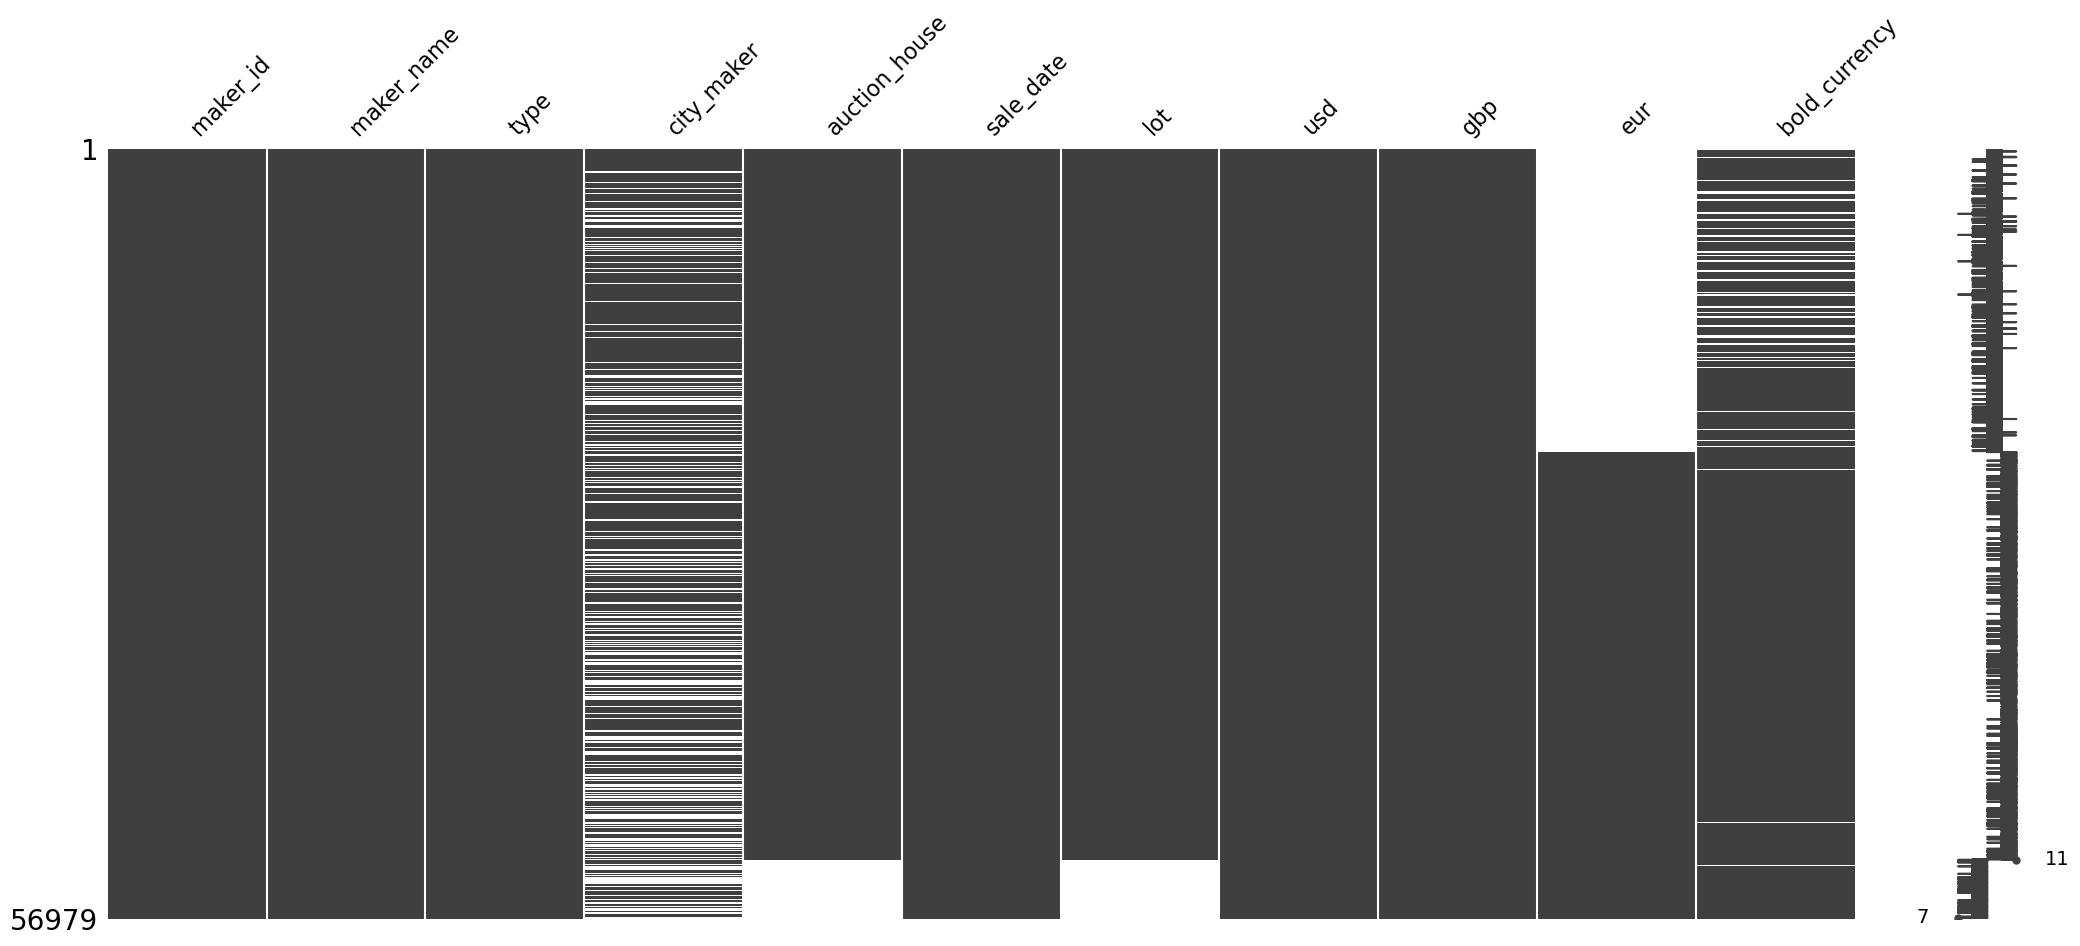

In [295]:
msno.matrix(sales)
plt.show()


Basically gbp and usd are never missing (it turns out they are missing exactly four times, and simultaneously), neither are maker_name and id and sale_date. Euro is missing if and only if the sale is old enough (until the 1990s, at the moment of the official existence of the euro). 
auction_house, like lot, is missing if and only if the sale is very recent ; bold currency almost always there recently ; no obvious pattern for city_maker and bold_currency

In [296]:
sales[sales.eur.isna()]
# last time euro was na is december 1998.

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency
43794,636,"Rugeri, Francesco",Cello,Cremona,Sotheby's,1829-05-03,-,357.0,70.0,NaN,gbp
48190,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,715.0,140.0,NaN,gbp
43083,623,"Rogeri, Giovanni Battista",Cello,Brescia,Puttick & Simpson,1850-11-28,-,368.0,72.0,NaN,gbp
48189,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,588.0,115.0,NaN,gbp
48188,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1853-05-28,-,606.0,110.0,NaN,gbp
...,...,...,...,...,...,...,...,...,...,...,...
47421,1356,"Smith, John",Violin,Falkirk,Phillip's,1998-12-10,35,1629.0,977.0,NaN,gbp
40677,1228,"Pickstone, Harry",Violin,Birmingham,Phillip's,1998-12-10,229,230.0,138.0,NaN,gbp
56608,971,"Wolff, Brothers",Violin,NaN,Phillip's,1998-12-10,194,575.0,345.0,NaN,gbp
49352,356,"Thibouville-Lamy, Jérôme Firm",Violin,NaN,Phillip's,1998-12-10,77,959.0,575.0,NaN,gbp


## Cardinality of categorical values

In [297]:
sales[['maker_name','maker_id','type','city_maker','auction_house']].nunique()

maker_name       3649
maker_id         3655
type               14
city_maker        732
auction_house      40
dtype: int64

There seems to be distinct makers who have the same name, which would not be entirely surprising.

In [298]:
# On compte le nombre d'IDs uniques par nom de fabricant
maker_counts = sales.groupby('maker_name')['maker_id'].nunique()

# On filtre ceux qui ont plus de 1 ID
multi_id_makers = maker_counts[maker_counts > 1].index.tolist()
print(f"Number of makers with multiple IDs: {len(multi_id_makers)}")
print("Namely:", multi_id_makers[:5])



Number of makers with multiple IDs: 4
Namely: ['Kennedy, Alexander', 'Meisel, Friedrich August', 'Smith, Thomas', 'Smith, William']


A quick look at the Tarisio Website shows that the two Friedrich August Meisel have different dates and are therefore different. The four William Smith and two Thomas Smith may safely assumed to be distinct makers as well (because of different cities for instance).

In [299]:
mapping_ids = sales.groupby('maker_name')['maker_id'].unique().reset_index()

mapping_ids['nb_ids'] = mapping_ids['maker_id'].apply(len)

doublons_ids = mapping_ids[mapping_ids['nb_ids'] > 1].sort_values(by='nb_ids', ascending=False)

display(doublons_ids)

,maker_name,maker_id,nb_ids
3083,"Smith, William","[13089, 15282, 13086, 13085]",4
1722,"Kennedy, Alexander","[15234, 2962]",2
2145,"Meisel, Friedrich August","[9716, 15325]",2
3082,"Smith, Thomas","[694, 13081]",2


In [300]:
import seaborn as sns

C:\Users\Pierre\AppData\Local\Temp\ipykernel_20076\836503132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


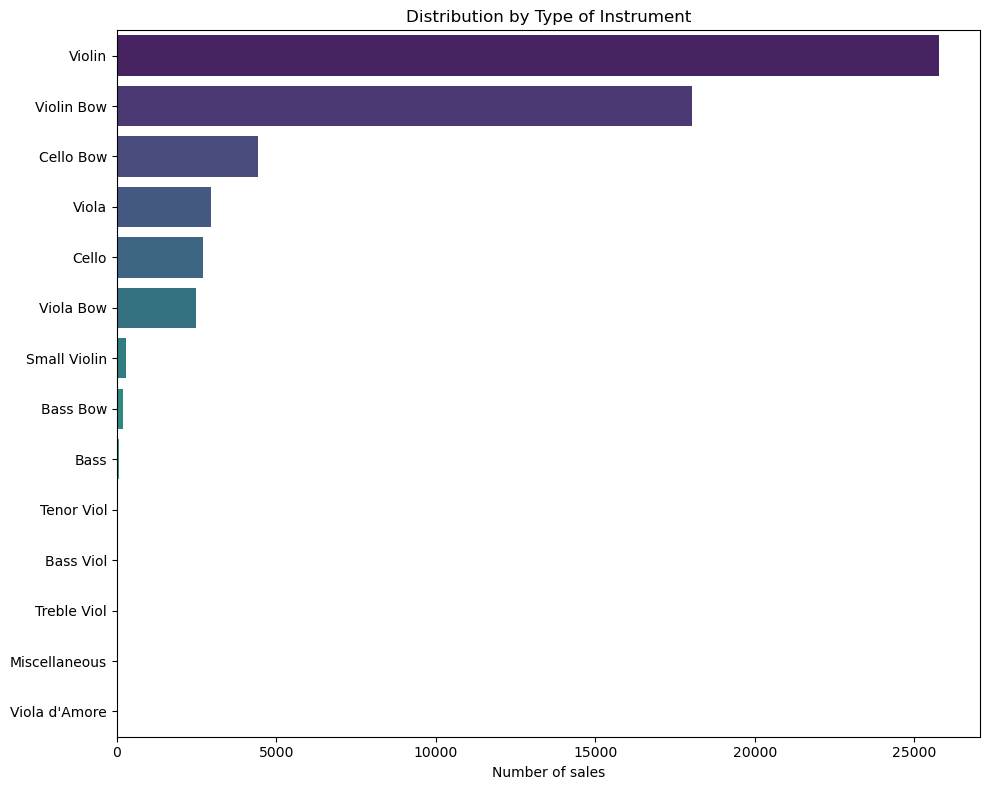

In [301]:
plt.figure(figsize=(10, 8)) 
sns.countplot(
    data=sales, 
    y='type', 
    order=sales['type'].value_counts().index,
    palette='viridis'
)

plt.title("Distribution by Type of Instrument")
plt.xlabel("Number of sales")
plt.ylabel("") 
plt.tight_layout() 
plt.show()

In [302]:
sales['usd'].describe()

count    5.697500e+04
mean     1.498607e+04
std      1.235086e+05
min      2.000000e+01
25%      1.544000e+03
50%      3.604000e+03
75%      9.351000e+03
max      1.582128e+07
Name: usd, dtype: float64

The mean is four times the median - a sign of a huge kurtosis. The distribution of prices is actually so right skewed that we cannot see anything on a histogram or distplot. We'll have to take the logarithm.

In [303]:
sales.city_maker.value_counts()

city_maker
Paris             8297
London            6157
Mirecourt         4336
Markneukirchen    2189
Cremona           1470
                  ... 
Massy                1
Ancarano             1
Fano                 1
Annecy               1
Morbegno             1
Name: count, Length: 732, dtype: int64

We now open the makers data set to explore it too.

In [304]:
maker_profiles=pd.read_csv("maker_profiles_ALL.csv",index_col='maker_id')

In [305]:
maker_profiles

,maker_name,role,date,info
maker_id,,,,
2919,"Achner, Michael",Violin maker,1724-1770,Michael Achner was the brother of Joseph and P...
2611,"Achner, Philip",Violin maker,1770-1800,Philip Achner created an oversized Stainer mod...
890,"Acoulon, Alexandre Alfred",Violin maker,1889-1914,Alexandre Alfred Acoulon was active in Paris i...
1662,"Acton, William John",Bow maker / Violin maker,1848-1931,"William John Acton was active from 1868, initi..."
1988,"Adam, Jean 'Grand'",Bow maker,1823-1869,"The most talented of the Adam bow makers, Jean..."
...,...,...,...,...
842,"Zurlini, Nicola",Violin maker,NaN,NaN
15425,"Zurschmiede, Christof",Violin maker,NaN,NaN
1262,"Zust, J. Emil",Bow maker / Violin maker,1864-1946,J. Emil Zust was a pupil of W.


### The feature 'maker_name' and a new feature 'last_name'

In [306]:
sales["maker_name"].value_counts()

maker_name
Hill & Sons, W. E. Firm          3268
Sartory, Eugène Nicolas          1324
Tubbs, James                      936
Nürnberger, Albert                723
Thibouville-Lamy, Jérôme Firm     689
                                 ... 
Strumphler, Jan                     1
Glass, Friedrich August II          1
Egan, Thomas                        1
Nehr, Pierre                        1
Hendel, Arno Erwin                  1
Name: count, Length: 3649, dtype: int64

In [307]:
sum(sales["maker_name"].value_counts()>1)
#2493 makers occur more than once in sales

2493

In [308]:
sum(sales["maker_name"].value_counts()>10)
#855 makers occur more than ten times in sales

855

In [309]:
i=0
while (sales["maker_name"].value_counts().cumsum()<30000).iloc[i]:
    i+=1
i
#the 151 most popular makers in our sales data set represent over 30k sales (hence over the half of the total)

151

In [310]:
# 1. Count occurrences (sales) per maker_id
maker_counts = sales['maker_id'].value_counts().sort_values()

# 2. Calculate the cumulative sum of sales
cumulative_sales = maker_counts.cumsum()

# 3. Define the threshold (25% of total sales)
total_sales = len(sales)
threshold = total_sales * 0.25

# 4. Identify makers who fall within this threshold
small_makers = maker_counts[cumulative_sales <= threshold]

# 5. The value 'x' is the maximum number of sales found in this group
x = small_makers.max()

print(f"The value x is: {x}")
print(f"Makers with {x} sales or fewer represent 25% of the total volume.")

The value x is: 24
Makers with 24 sales or fewer represent 25% of the total volume.


With over 1000 makers having a single sale, and 25% of sales come from makers with at most 24 sales, it will be useful to group makers in some way. One way could be family.

In [311]:
def last_name(name):
    return name.split(",")[0]

In [312]:
sales["maker_last_name"]=sales["maker_name"].apply(last_name)

In [313]:
maker_profiles["maker_last_name"]=maker_profiles["maker_name"].apply(last_name)

In [314]:
maker_profiles["maker_last_name"].value_counts()
#17 different makers were called Gagliano, a proper dynasty of makers.

maker_last_name
Gagliano        17
Hornsteiner     16
Pfretzschner    15
Schmidt         15
Fischer         14
                ..
Zurlini          1
Zurschmiede      1
Zust             1
Zwerger          1
Zygmuntowicz     1
Name: count, Length: 3397, dtype: int64

In [315]:
sum(maker_profiles["maker_last_name"].value_counts()>10)
#10 families have at least 10 members in the sales set. Thus with the last_name feature, we won't be able to massively group makers.

10

## The sale_date feature

<Axes: >

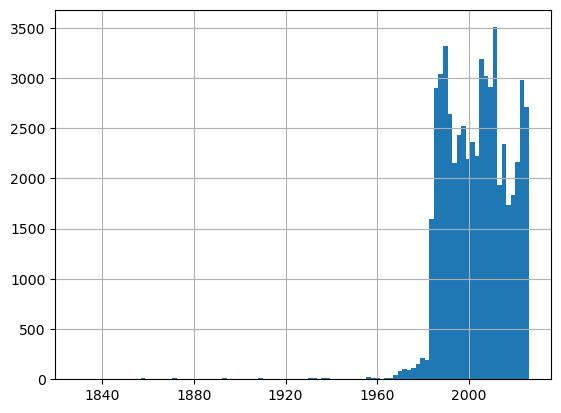

In [316]:
sales.sale_date.hist(bins=100)
#sales year run from 1825 to 2026 but almost all sales are post 1980

<Axes: >

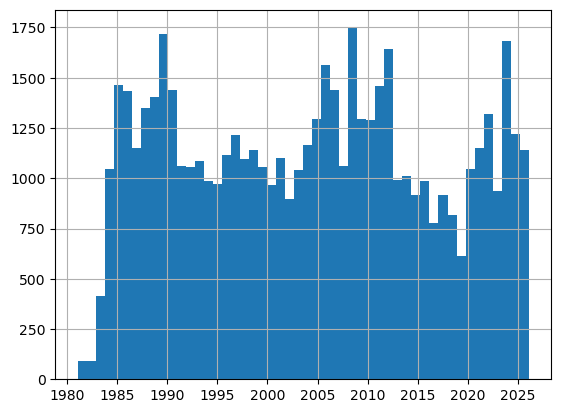

In [317]:
sales[sales.sale_date.dt.year>1980].sale_date.hist(bins=50)


Since 1984, the frequency of sales seem more or less homogenous.

In [318]:
(sales.sale_date.dt.year>1980).mean()
#98% of sales are post 1980

np.float64(0.9807297425367241)

## The price feature(s) - The target

Given the kurtosis, we'll take the log of the price.

In [319]:
sales['log_usd']=sales.usd.apply(np.log)

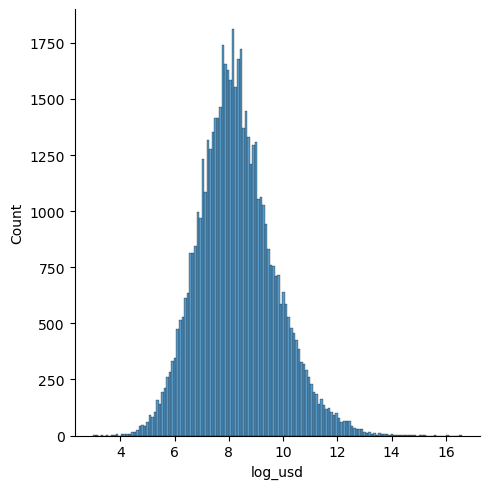

In [320]:
sns.displot(data=sales,x="log_usd")
#still a little right-skewed, but fairly normally distributed

## Price and the 'type' feature

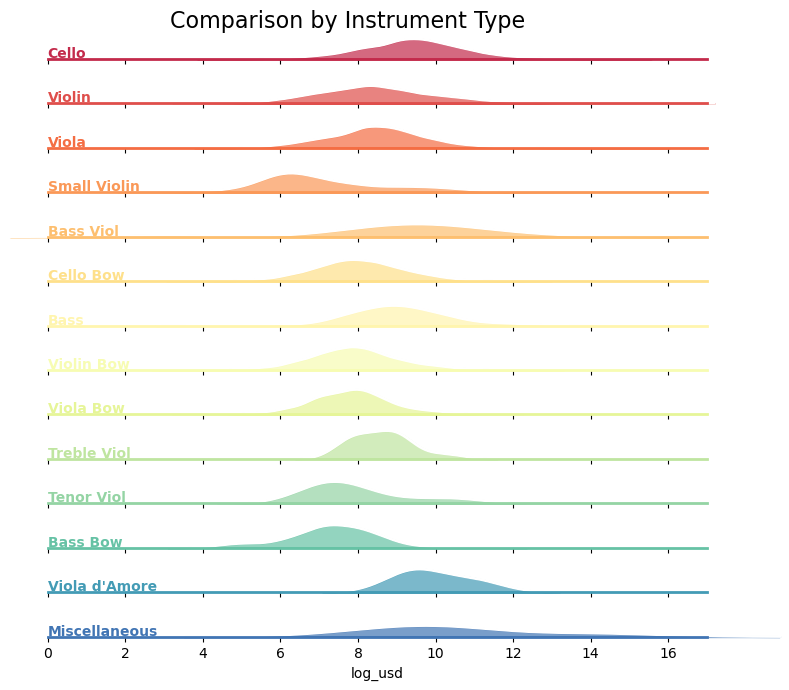

In [321]:
# Function to label each subplot
def label(x, color, label):
    ax = plt.gca()
    # Position the label closer to the left
    ax.text(4.0, 0.2, label, fontweight="bold", color=color, ha="left", va="center")

# Create a ridge plot using seaborn FacetGrid
g = sns.FacetGrid(sales, row="type", hue="type", aspect=15, height=0.5, palette="Spectral")

# Plot the KDE with fill
g.map(sns.kdeplot, "log_usd", clip_on=False, fill=True, alpha=0.7, linewidth=1.5)

# Add a white outline
g.map(sns.kdeplot, "log_usd", clip_on=False, color="w", lw=2)

# Add horizontal line at y=0
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Function to label each subplot
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, 0.2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)

g.map(label, "log_usd")

# Adjust subplots to overlap
g.fig.subplots_adjust(hspace=0.5)

# Remove titles and y-ticks
g.set_titles("")
g.set(yticks=[])
g.set(xlim=(0, 17))
g.set_ylabels("")
g.despine(bottom=True, left=True)

# Set overall title
g.fig.suptitle("Comparison by Instrument Type", fontsize=16)
plt.show()

<Axes: xlabel='log_usd'>

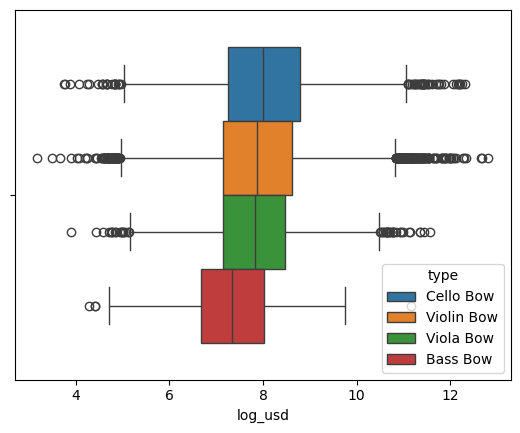

In [322]:
data_bow=sales[sales.type.str.contains('Bow')]
sns.boxplot(data=data_bow,x='log_usd',hue='type')
# different types of bows have similar price distributions

Looks like the four types of bows have similar price distributions. Bass bows tend to be cheaper but there are much fewer occurrences of them.

## Impact of the maker on the price

We want to visualise the distribution of prices by maker. We use Ridgeplot and display the top 10 and the bottom 10 of the makers with at least 50 sales in the data base.

In [323]:
counts = sales['maker_name'].value_counts()
makers_50 = counts[counts >= 50].index

medians_50 = sales[sales['maker_name'].isin(makers_50)].groupby('maker_name')['log_usd'].median().sort_values(ascending=False)

top_10 = medians_50.head(10).index.tolist()
bottom_10 = medians_50.tail(10).index.tolist()

selection_makers = top_10 + bottom_10
df_extremes = sales[sales['maker_name'].isin(selection_makers)].copy()

df_extremes['maker_name'] = pd.Categorical(df_extremes['maker_name'], categories=selection_makers, ordered=True)

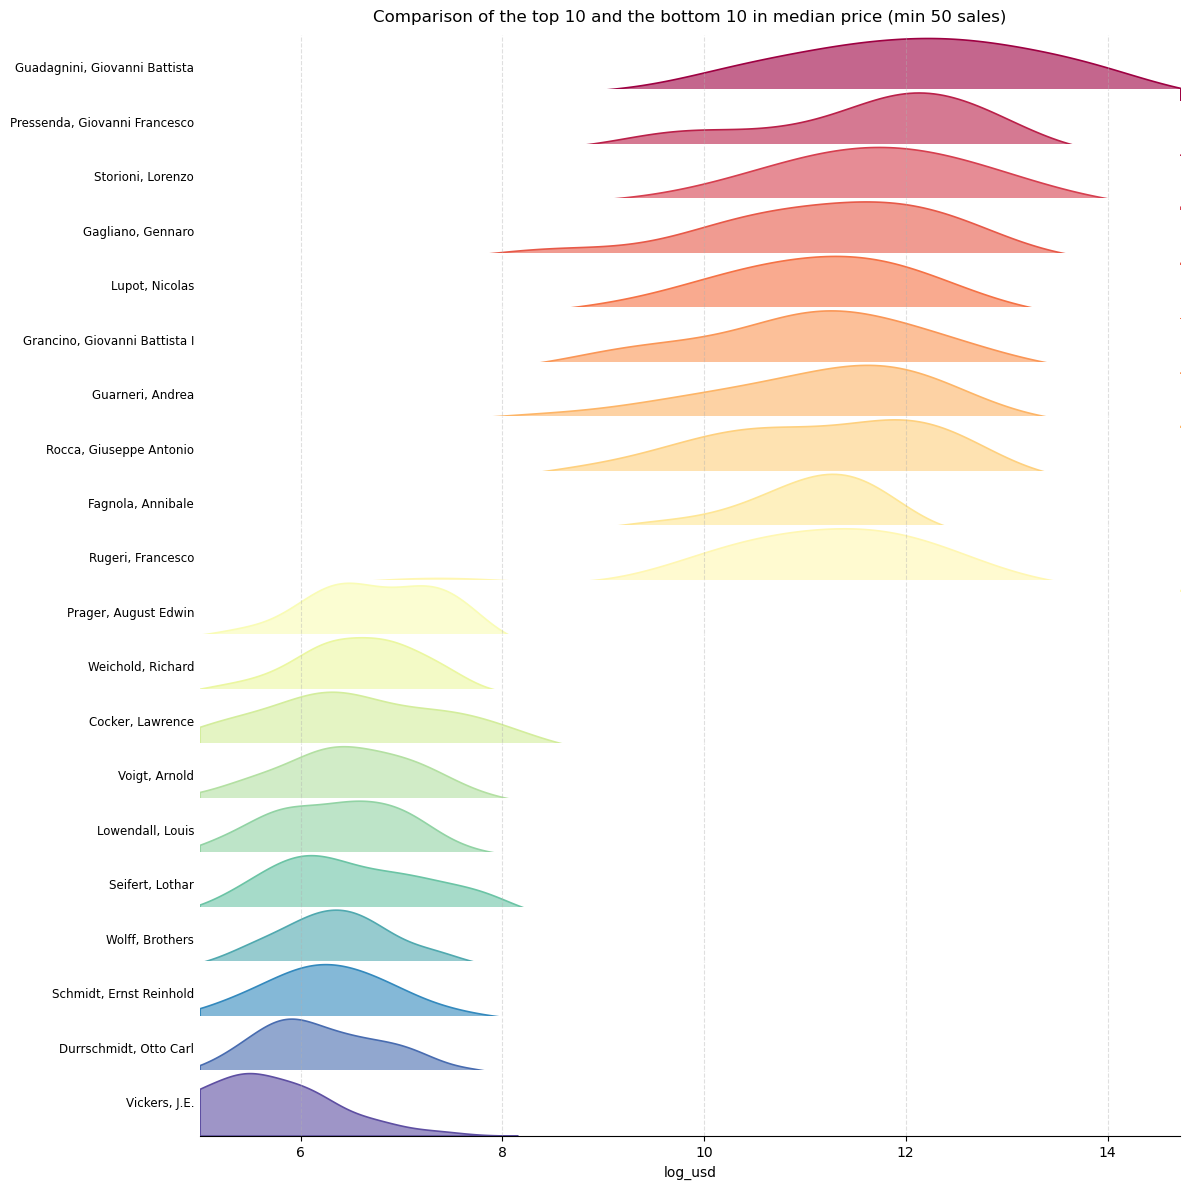

In [324]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Palette Spectral avec autant de couleurs que de makers
n = len(selection_makers)
palette = [cm.Spectral(i / (n - 1)) for i in range(n)]

fig, axes = plt.subplots(n, 1, figsize=(12, 12), sharex=True)

x_min = 5
x_max = df_extremes['log_usd'].max()

for i, (maker, ax, color) in enumerate(zip(selection_makers, axes, palette)):
    subset = df_extremes[df_extremes['maker_name'] == maker]['log_usd']
    
    sns.kdeplot(
        data=subset,
        ax=ax,
        fill=True,
        color=color,
        alpha=0.6,
        linewidth=1.2,
        clip=(x_min, x_max)
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylabel(maker, rotation=0, ha='right', va='center', fontsize=8.5)
    ax.set_yticks([])
    ax.set_xlabel('')
    
    # Supprimer les bordures sauf le bas du dernier
    for spine in ['top', 'left', 'right']:
        ax.spines[spine].set_visible(False)
    if i < n - 1:
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(bottom=False)
    
    ax.grid(axis='x', linestyle='--', alpha=0.4)

axes[0].set_title(
    "Comparison of the top 10 and the bottom 10 in median price (min 50 sales)",
    fontsize=12, pad=10
)
axes[-1].set_xlabel('log_usd', fontsize=10)

plt.tight_layout(h_pad=-0.8)  # h_pad négatif = overlap entre subplots
plt.show()

The top 10 is clearly italian, except for one Frenchman. We also see that the distribution of the top 10 is almost entirely disjoint from the distribution of the bottom 10, with modes being about 6 apart in log units - a factor of over 400 in real prices! The most famous liutaio ever, Antonio Stradivari, is not in the top 10 but not far.

In [325]:
sales.groupby('maker_name')['log_usd'].describe().loc['Stradivari, Antonio']

count    192.000000
mean      10.563426
std        2.735904
min        4.700480
25%        7.956263
50%       10.645209
75%       12.672898
max       16.576867
Name: Stradivari, Antonio, dtype: float64

## Evolution of prices with time

<Axes: xlabel='sale_date', ylabel='log_usd'>

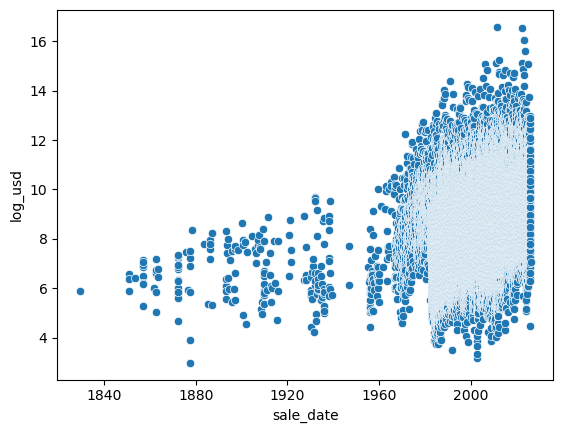

In [326]:
sns.scatterplot(data=sales,x='sale_date',y='log_usd')

We do observe some inflation across the years, but it is much more visible at the upper limit of the hull than the lower.

In [327]:
mask_recent=sales.sale_date.dt.year>1985
sales_recent=sales[mask_recent]
sales_recent['year']=sales.sale_date.dt.year

In [328]:
def decade(year):
    a=(year-1986) // 10
    return f"{1986+10*a}-{1986+10*a+9}"

In [329]:
sales_recent=sales_recent[sales_recent["year"]<2026]
sales_recent["decade"]=sales_recent["year"].apply(decade)

In [330]:
sales

,maker_id,maker_name,type,city_maker,auction_house,sale_date,lot,usd,gbp,eur,bold_currency,maker_last_name,log_usd
43794,636,"Rugeri, Francesco",Cello,Cremona,Sotheby's,1829-05-03,-,357.0,70.0,NaN,gbp,Rugeri,5.877736
48190,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,715.0,140.0,NaN,gbp,Stradivari,6.572283
43083,623,"Rogeri, Giovanni Battista",Cello,Brescia,Puttick & Simpson,1850-11-28,-,368.0,72.0,NaN,gbp,Rogeri,5.908083
48189,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1850-11-28,-,588.0,115.0,NaN,gbp,Stradivari,6.376727
48188,722,"Stradivari, Antonio",Violin,Cremona,Puttick & Simpson,1853-05-28,-,606.0,110.0,NaN,gbp,Stradivari,6.406880
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41556,1213,"Prager, Gustav Adolf",Violin Bow,NaN,NaN,2025-11-21,NaN,755.0,577.0,655.0,eur,Prager,6.626718
27705,1638,"Kunze, Wilhelm Paul",Violin,The Hague,NaN,2025-11-21,NaN,2719.0,2078.0,2360.0,eur,Kunze,7.908019
21491,7609,"Hendel, Arno Erwin",Violin,NaN,NaN,2025-11-21,NaN,2405.0,1838.0,2088.0,eur,Hendel,7.785305
4402,63,"Bernardel, Gustave Adolphe",Violin,Paris,NaN,2025-12-05,NaN,4800.0,3597.0,4122.0,usd,Bernardel,8.476371


In [331]:
sales_recent.groupby('decade')['log_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
decade,,,,,,,,
1986-1995,13766.0,7.784879,1.306811,3.496508,6.887808,7.642524,8.518293,14.389642
1996-2005,12645.0,8.219501,1.297456,3.178054,7.337588,8.095599,8.956995,14.524531
2006-2015,14005.0,8.562824,1.379879,3.871201,7.656810,8.411833,9.367344,16.576867
2016-2025,11713.0,9.019678,1.217599,4.488636,8.188689,8.865029,9.729134,16.545974


There the general increase of price is visible, and regular.

## Currencies and bold_currency

In [332]:
sales.bold_currency.value_counts()

bold_currency
gbp    31631
usd    15974
eur     5324
Name: count, dtype: int64

## auction_house feature

In [333]:
sales.auction_house.value_counts()

auction_house
Tarisio                                  12441
Sotheby's                                10944
Phillip's                                 6386
Christie's                                4855
Skinner                                   4077
Bonhams                                   3420
Bongartz's                                3277
Vichy-Enchères                            2062
Brompton's                                1673
Ingles & Hayday                           1419
Sotheby Parke Bernet                       283
Millon & Associés (Gilles Chancereul)      274
Puttick & Simpson                          208
Dorotheum                                  207
Guy Laurent                                174
Gardiner-Houlgate                          161
T2 Auctions                                153
Ader Tajan                                 139
da Salo Auction                            130
Tajan                                       73
Butterfield & Butterfield                   60

40 different auction houses appear, of which 9 appear a single time. The Tarisio house is obviously the most frequent. 19 of them appear more than 100 times. Sotheby Parke Bernet and Sotheby's are the two names of the same auction house at different points in time.

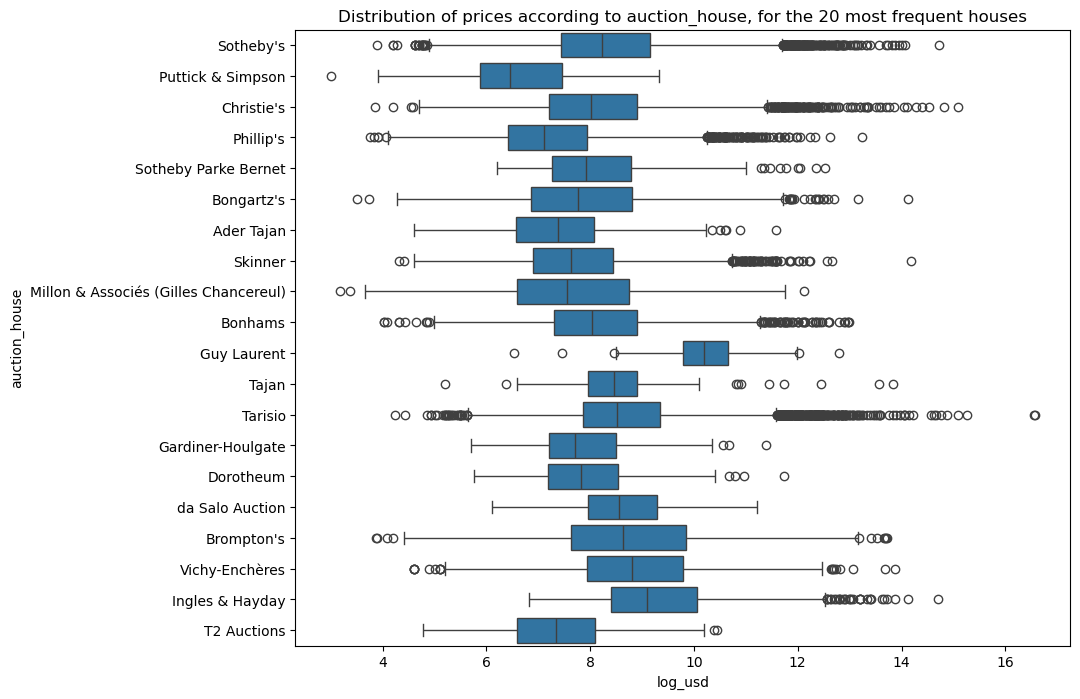

In [334]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

top20=sales.auction_house.value_counts().index[:20]

sns.boxplot(data=sales.loc[sales.auction_house.isin(top20)], x='log_usd', y='auction_house')

plt.title('Distribution of prices according to auction_house, for the 20 most frequent houses')
plt.show()

One big house achieved incredible results, Guy Laurent. The most represented houses - the highest on the graph - did not necessarily make the best results.

<Axes: >

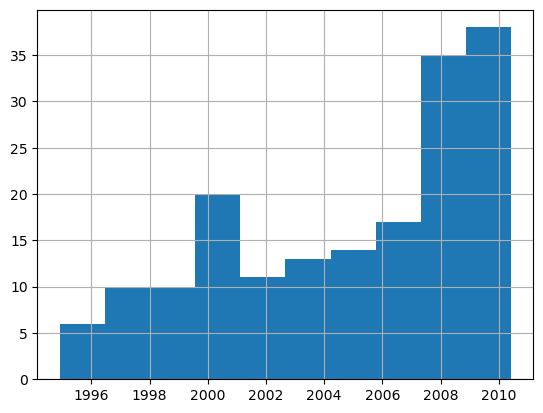

In [335]:
sales[sales['auction_house']=='Guy Laurent']['sale_date'].hist()

Guy Laurent has 174 sales archived here, some of them feature particularly famous makers such as Jean Adam. it seems that it made sales from 1994 to 2010. In particular it didn't sell the last 15 years, where prices increased significantly, which makes the sensational prices particularly remarkable.

## Dates of makers

In [336]:
sum(maker_profiles.date.isna())

1499

1500 out 5000 maker_profiles have no dates, which is a problem in a bid to exploit the era a maker lives in to evaluate his work. However many of them belong to the 1300 makers which have actually 0 sale in our data set.

Let's have a look at these makers which have no date.

In [337]:
maker_profiles[maker_profiles['date'].isna()]

,maker_name,role,date,info,maker_last_name
maker_id,,,,,
15467,"Aerts, René & Marcel",Violin maker,NaN,NaN,Aerts
15601,"Aguzzi, Dario",Violin maker,NaN,NaN,Aguzzi
1676,"Albani, Michele",Violin maker,NaN,NaN,Albani
15592,"Alberini, Guido",Violin maker,NaN,NaN,Alberini
15279,"Albert, Ádám Karóly",Violin maker,NaN,NaN,Albert
...,...,...,...,...,...
840,"Zobboli, Bruno",Violin maker,NaN,NaN,Zobboli
3072,"Zoephel, Willy",Violin maker,NaN,NaN,Zoephel
15411,"Zucker, Frantisek",–,NaN,NaN,Zucker


Those with no date all seem to have no info. And it is not an artefact of the scraping, the website genuinely gives no info about them.

In [338]:
ids_a_filtrer = maker_profiles.loc[maker_profiles['date'].isna()].index
len(sales[sales['maker_id'].isin(ids_a_filtrer)])

6434

These makers, which represent almost one third of the makers' list, represent less 11% of the sales. But that's not quite negligible.

In [339]:
import re

def birth_cent(date_str):
    if not isinstance(date_str, str) or date_str.lower() == 'nan':
        return pd.NA
    
    match = re.search(r'\d{3,4}', date_str)
    
    if match:
        annee = int(match.group())
        
        
        if annee % 100 == 0:
            siecle_num = annee // 100
        else:
            siecle_num = (annee // 100) + 1
            
        return siecle_num
    
    return pd.NA



In [340]:
maker_profiles['birth_cent']=maker_profiles['date'].apply(birth_cent)

In [341]:
maker_profiles['birth_cent'].value_counts()

birth_cent
19    1640
18     811
20     772
17     201
16      22
21       3
2        1
15       1
Name: count, dtype: int64

In [342]:
maker_profiles[maker_profiles['birth_cent']==2]
#that's clearly a mistake, we'll make the century XVIIIth.

,maker_name,role,date,info,maker_last_name,birth_cent
maker_id,,,,,,
6205,"Ficker, Johann Gottlob II",Violin maker,178-1827,Johann Gottlob Ficker was the son and pupil of...,Ficker,2


In [343]:
maker_profiles.loc[maker_profiles['birth_cent']==2,'birth_cent']=18


In [344]:
maker_profiles['birth_cent'].value_counts()

birth_cent
19    1640
18     812
20     772
17     201
16      22
21       3
15       1
Name: count, dtype: int64

In [345]:
def birth_cent_from_id(maker_id):
    return birth_cent(maker_profiles.loc[maker_id,'date'])

In [346]:
sales['birth_cent']=sales['maker_id'].apply(birth_cent_from_id)

In [347]:
sales.birth_cent.value_counts()

birth_cent
19    31914
18     8517
20     7916
17     2024
16      174
Name: count, dtype: int64

The plot below show that instruments from older centuries are more valued than newer.

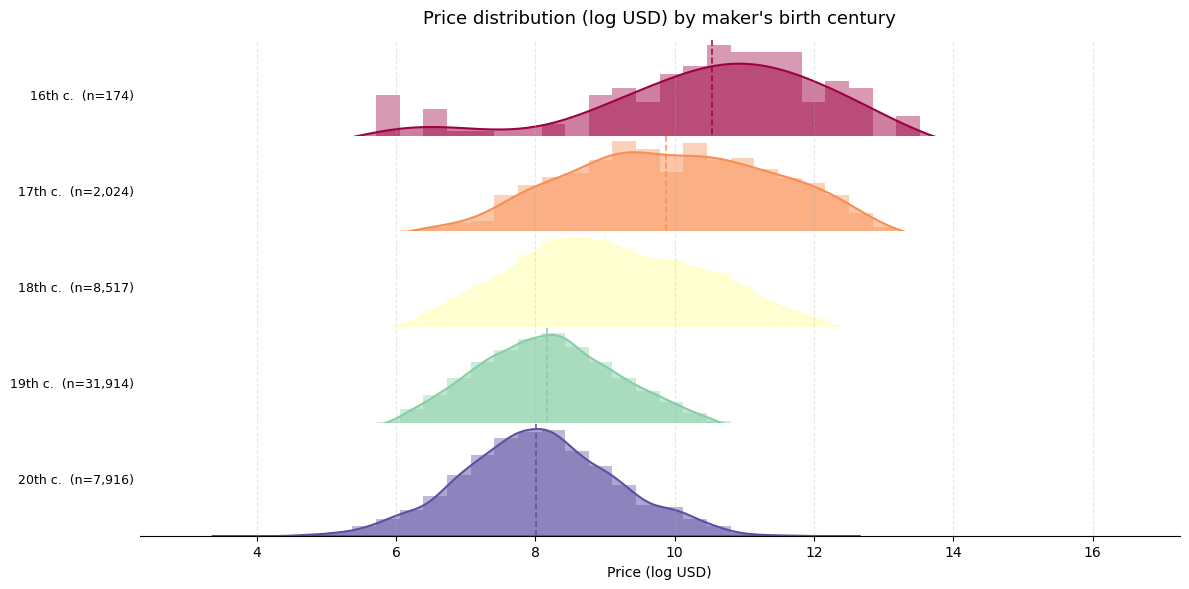

In [348]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

df_plot = sales.dropna(subset=['birth_cent']).copy()
df_plot['birth_cent'] = df_plot['birth_cent'].astype(int)
centuries = sorted(df_plot['birth_cent'].unique())

n = len(centuries)
palette = [cm.Spectral(i / (n - 1)) for i in range(n)]

fig, axes = plt.subplots(n, 1, figsize=(12, n * 1.2), sharex=True)

x_min = df_plot['log_usd'].min()
x_max = df_plot['log_usd'].max()

for i, (century, ax, color) in enumerate(zip(centuries, axes, palette)):
    subset = df_plot[df_plot['birth_cent'] == century]['log_usd']

    ax.hist(subset, bins=40, color=color, alpha=0.4,
            density=True, range=(x_min, x_max))
    
    sns.kdeplot(
        data=subset,
        ax=ax,
        fill=True,
        color=color,
        alpha=0.5,
        linewidth=1.5,
        clip=(x_min, x_max)
    )

    # Add median line
    median = subset.median()
    ax.axvline(median, color=color, linewidth=1.2,
               linestyle='--', alpha=0.9)

    label = f"{century}th c.  (n={len(subset):,})"
    ax.set_ylabel(label, rotation=0, ha='right',
                  va='center', fontsize=9)
    ax.set_yticks([])

    for spine in ['top', 'left', 'right']:
        ax.spines[spine].set_visible(False)
    if i < n - 1:
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(bottom=False)

    ax.grid(axis='x', linestyle='--', alpha=0.3)

axes[0].set_title(
    "Price distribution (log USD) by maker's birth century",
    fontsize=13, pad=12
)
axes[-1].set_xlabel('Price (log USD)', fontsize=10)

plt.tight_layout(h_pad=-1.2)
plt.show()

In [349]:
# maker_profiles.reset_index().to_csv("./Data/Tarisio_Data/maker_profiles_engineered.csv",index=False)
# commented out because file is already saved